In [2]:
import pymaid
import navis as nv
import matplotlib.pyplot as plt
import time
from neuroboom import dendrogram as nbd
import neuroboom as nb

instance = pymaid.CatmaidInstance(server='https://radagast.hms.harvard.edu/dorsalhorn/',
                            api_token='REPLACE_WITH_YOUR_CATMAID_API_TOKEN',
                            project_id=14,
                            http_user='', # omit if not required
                            http_password='') # omit if not required
#get ya neuron
neuron = pymaid.get_neuron([236739
,236888
,237231
,237299
,237408
,237753])

INFO  : Global CATMAID instance set. Caching is ON. (pymaid)


Fetch neurons:   0%|          | 0/6 [00:00<?, ?it/s]

Make nrn:   0%|          | 0/6 [00:00<?, ?it/s]

In [3]:
def find_tag(key,neuron):
    if key in neuron.connector_tags.keys():
        return neuron.connector_tags[key]
    else:
        return []

In [4]:
pd=[]
vd=[]
preaxon=[]
predendrite=[]
selfffi=[]
selfpsi=[]
for index,n in enumerate(neuron):
    pd+=find_tag('pd',n)
    vd+=find_tag('vd',n)
    preaxon+=find_tag('pre-vaxon',n)
    predendrite+=find_tag('pre-vdendrite',n)
    selfffi+=find_tag('self-ffi',n)
    selfpsi+=find_tag('self-psi',n)
len(preaxon),len(pd+vd)

(25, 139)

In [5]:
len(selfffi)/len(pd),len(pd)

(0.015151515151515152, 132)

Pruning:   0%|          | 0/6 [00:00<?, ?it/s]

Plot neurons:   0%|          | 0/6 [00:00<?, ?it/s]

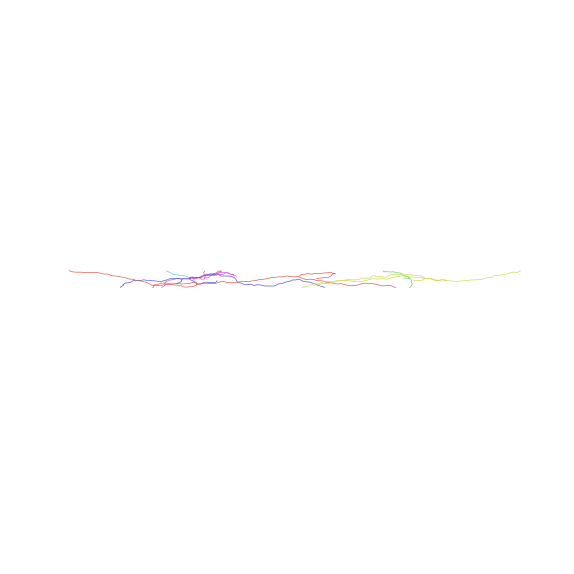

In [6]:
#visulaize the morphology of pruned neuron
n_pr_size = nv.prune_twigs(neuron,
                         size='4 microns',
                         recursive=float('inf'),
                         inplace=False)
fig, ax = n_pr_size.plot2d()  # equivalent to `navis.plot2d(nl)`
plt.show()

In [7]:
#define functions to return the parent node id of node that survide after pruning
def parent_id(x):
    parent=neuron.nodes[neuron.nodes['node_id']==x]['parent_id'].values[0]
    return parent

def parent_after_prune(x):
    while sum(n_pr_size.nodes['node_id'].isin([x]))==0:
        x=parent_id(x)
        
    return x


In [8]:
#relocate the connectors
for j in neuron:
    cn = j.connectors
    id_prune=[]
    for i in cn['node_id']:
        id_prune.append(parent_after_prune(i))
    
    cn['node_id']=id_prune

In [9]:
#pruned the neuron
pruned= nv.prune_twigs(neuron,
                         size='4 microns',
                         recursive=float('inf'),
                         inplace=False)

Pruning:   0%|          | 0/6 [00:00<?, ?it/s]

In [10]:
pruned

,type,name,skeleton_id,n_nodes,n_connectors,n_branches,n_leafs,cable_length,soma,units
0,CatmaidNeuron,neuron 236740,236739,292,18,2,4,310271.031250,None,1 nanometer
1,CatmaidNeuron,neuron 236889,236888,262,47,2,4,256086.687500,None,1 nanometer
...,...,...,...,...,...,...,...,...,...,...
4,CatmaidNeuron,neuron 237409,237408,227,48,2,4,182072.437500,None,1 nanometer
5,CatmaidNeuron,neuron 237754,237753,198,32,4,6,130471.507812,None,1 nanometer


In [11]:
#calculate the distance, unit is nm
m=[]
for i,j in enumerate(pruned):
    m.append(nv.geodesic_matrix(j,weight='weight'))

In [12]:
def find_tag(key,neuron):
    if key in neuron.connector_tags.keys():
        return neuron.connector_tags[key]
    else:
        return []
    

In [13]:
psi_close=[]
import numpy as np
for index,neuron in enumerate(pruned):
    psi_connector=find_tag('pre-vaxon',neuron)
    psi_node=np.zeros(len(psi_connector))
    for i,node in enumerate(psi_connector):
        psi_node[i]=neuron.connectors[neuron.connectors['connector_id']==node]['node_id']
 
    pd_connector=find_tag('pd',neuron)+find_tag('vd',neuron)
    pd_node=np.zeros(len(pd_connector))
    for i,node in enumerate(pd_connector):
        pd_node[i]=neuron.connectors[neuron.connectors['connector_id']==node]['node_id']
    pd_to_psi=m[index].loc[psi_node, pd_node]
    psi_close+=(list((pd_to_psi < 4000).sum()))

In [14]:
len(psi_close)

139

In [17]:
np.savez("trpm8_pre-vaxon_final.npz", psi_close=np.array(psi_close))

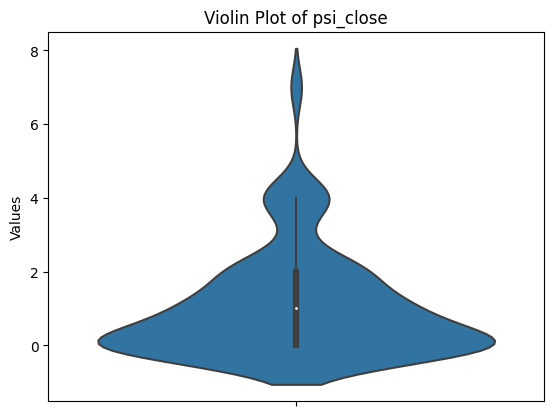

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
# Create a violin plot
sns.violinplot(y=psi_close)

# Add title and labels
plt.title('Violin Plot of psi_close')
plt.ylabel('Values')

# Show the plot
plt.show()